# Airbnb Data Exploration
### Pre-analysis inspection of listings and reviews across 15 US cities
---
Work through each section top to bottom. Run one cell at a time with **Shift+Enter**.  
Change `CITY` in Section 2 to inspect any individual city before combining.


## 0. Imports & Config

In [9]:
import os
import glob
import sqlite3
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.2f}".format)

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR = os.path.expanduser("~/Desktop/MSIS/TEXT_MINING_NLP/Project/code2")
CSV_DIR  = os.path.join(BASE_DIR, "csv")
DB_PATH  = os.path.join(BASE_DIR, "airbnb.db")

CITY = "Austin_TX"  # change to inspect any city

print("Base dir:", BASE_DIR)
print("CSV dir exists:", os.path.exists(CSV_DIR))
print("DB exists:", os.path.exists(DB_PATH))



Base dir: /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2
CSV dir exists: True
DB exists: False


---
## 1. File Inventory
Check all 15 cities have both a listings and reviews file, and that file sizes look sensible.


In [12]:
listing_files = sorted(glob.glob(os.path.join(CSV_DIR, "listings_*.csv")))
review_files  = sorted(glob.glob(os.path.join(CSV_DIR, "reviews_*.csv")))

rows = []
for lpath in listing_files:
    city_tag = os.path.basename(lpath).replace("listings_","")
    rpath    = os.path.join(CSV_DIR, f"reviews_{city_tag}.csv")
    rows.append({
        "city"            : city_tag,
        "listing_file"    : "✅" if os.path.exists(lpath) else "❌",
        "review_file"     : "✅" if os.path.exists(rpath) else "❌",
        "listing_size_MB" : round(os.path.getsize(lpath)/1e6, 1) if os.path.exists(lpath) else None,
        "review_size_MB"  : round(os.path.getsize(rpath)/1e6, 1) if os.path.exists(rpath) else None,
    })

inventory_df = pd.DataFrame(rows)
print(f"Total cities found: {len(inventory_df)}")
inventory_df

Total cities found: 15


,city,listing_file,review_file,listing_size_MB,review_size_MB
0,Austin_TX.csv,✅,❌,28.10,None
1,Boston_MA.csv,✅,❌,7.90,None
2,Cambridge_MA.csv,✅,❌,3.40,None
3,Chicago_IL.csv,✅,❌,22.30,None
4,Denver_CO.csv,✅,❌,13.20,None
5,Hawaii_HI.csv,✅,❌,87.10,None
6,LosAngeles_CA.csv,✅,❌,112.00,None
7,Nashville_TN.csv,✅,❌,26.30,None
8,NewOrleans_LA.csv,✅,❌,18.90,None
9,NewYorkCity_NY.csv,✅,❌,65.80,None


In [ ]:
# Optional: after running 01_ingest.py, inspect Parquet with the same ID logic
PARQUET_DIR = os.path.join(BASE_DIR, "parquet")
pq_reviews = os.path.join(PARQUET_DIR, "reviews_raw.parquet")
if os.path.exists(pq_reviews):
    df_pq = pd.read_parquet(pq_reviews)
    for c in REVIEW_ID_COLS:
        if c in df_pq.columns:
            df_pq[c] = _strip_excel_id_strings(df_pq[c])
    print("reviews_raw.parquet:", review_id_duplicate_report(df_pq))
    print(df_pq.shape)
else:
    print("No parquet yet — run 01_ingest.py or use CSV cells below.")

reviews_raw.parquet rows: 9106416
review rows in duplicate-id groups: 0
(9106416, 7)


In [4]:
# ── Duplicate-ID audit for a single city ──────────────────────────────────
# Uses _read_listings() from Cell 2, which applies full precision-loss repair.
def audit_listing_ids(file):
    df = _read_listings(file)
    dupes = df[df.duplicated(subset='id', keep=False)]
    print(f"{os.path.basename(file)}")
    print(f"  Total rows        : {len(df):,}")
    print(f"  Unique IDs        : {df['id'].nunique():,}")
    print(f"  Duplicate ID rows : {len(dupes):,}")
    if len(dupes):
        print("  Sample duplicate IDs:", dupes['id'].value_counts().head(5).to_dict())
    return df

# Quick test on the selected city
lpath = os.path.join(CSV_DIR, f"listings_{CITY}_clean.csv")
if os.path.exists(lpath):
    audit_listing_ids(lpath)


In [5]:
# ── Review-ID audit for a single city ────────────────────────────────────
def audit_review_ids(file):
    df = _read_reviews(file)
    print(f"{os.path.basename(file)}")
    print(f"  Total rows           : {len(df):,}")
    print(f"  Unique listing_ids   : {df['listing_id'].nunique():,}")
    if 'id' in df.columns:
        print(f"  Duplicate review ids : {df.duplicated(subset='id').sum():,}")
    return df

rpath = os.path.join(CSV_DIR, f"reviews_{CITY}_clean.csv")
if os.path.exists(rpath):
    audit_review_ids(rpath)


---
## 2. Inspect a Single City — Listings
Load one city's listings CSV and explore its shape, columns, types and nulls.  
Change `CITY` in Section 0 to switch cities.


In [8]:
lpath = os.path.join(CSV_DIR, f"listings_{CITY}_clean.csv")
df_l  = _read_listings(lpath)  # ID columns normalised automatically

print(f"Shape: {df_l.shape[0]:,} rows × {df_l.shape[1]} columns")
df_l.head()


Shape: 10,533 rows × 80 columns


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,...,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,listing_city
0,5456,https://www.airbnb.com/rooms/5456,20250900000000.00,9/17/25,city scrape,"Walk to 6th, Rainey St and Convention Ctr","Great central location for walking to Convention Center, Rainey Street, Eas...",My neighborhood is ideally located if you want to walk to bars and restauran...,https://a0.muscache.com/pictures/14084884/b5a35a84_original.jpg,8028,https://www.airbnb.com/users/show/8028,Sylvia,2/16/09,"Austin, TX",I am a licensed Real Estate Broker and owner of Armadillo Realty. I attende...,within a few hours,100%,90%,t,https://a0.muscache.com/im/users/8028/profile_pic/1329882962/original.jpg?ak...,https://a0.muscache.com/im/users/8028/profile_pic/1329882962/original.jpg?ak...,East Downtown,1.00,2.00,"['email', 'phone']",...,9/17/25,708,25,1,81,33,150,14550.00,3/19/09,9/2/25,4.85,4.88,4.86,4.90,4.82,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, TX"
1,6448,https://www.airbnb.com/rooms/6448,20250900000000.00,9/17/25,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & Airy","Clean, private space with everything you need for a quiet, comfy, private st...",The neighborhood is fun and funky (but quiet)! People are friendly and you ...,https://a0.muscache.com/pictures/airflow/Hosting-6448/original/a0ab6e9c-58ed...,14156,https://www.airbnb.com/users/show/14156,Amy,4/20/09,"Austin, TX","We are a family of four (with teenagers, all of us vaccinated). We love our ...",within an hour,100%,96%,t,https://a0.muscache.com/im/users/14156/profile_pic/1413388190/original.jpg?a...,https://a0.muscache.com/im/users/14156/profile_pic/1413388190/original.jpg?a...,Zilker,1.00,2.00,"['email', 'phone']",...,9/17/25,339,14,1,61,20,84,13440.00,9/6/11,8/20/25,4.97,4.97,4.96,4.99,4.98,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, TX"
2,8502,https://www.airbnb.com/rooms/8502,20250900000000.00,9/17/25,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located in a 1950s neighborhood less th...,NaN,https://a0.muscache.com/pictures/miso/Hosting-8502/original/be48ea3b-6d8a-4d...,25298,https://www.airbnb.com/users/show/25298,Karen,7/11/09,"Austin, TX",I handle the reservations at the studio on the lower level of a house that b...,within a day,100%,60%,f,https://a0.muscache.com/im/users/25298/profile_pic/1330879914/original.jpg?a...,https://a0.muscache.com/im/users/25298/profile_pic/1330879914/original.jpg?a...,East Riverside,1.00,1.00,"['email', 'phone']",...,9/17/25,54,1,0,88,2,8,304.00,2/19/10,5/5/25,4.57,4.55,4.67,4.85,4.88,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, TX"
3,13035,https://www.airbnb.com/rooms/13035,20250900000000.00,9/17/25,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very centrally located on Austin's Eas...,East Cesar Chavez is a gentrifying urban area that remains highly diverse. G...,https://a0.muscache.com/pictures/miso/Hosting-13035/original/00407f5f-ff1f-4...,50793,https://www.airbnb.com/users/show/50793,Margaret Ann,11/2/09,"Austin, TX","We're a responsible, easygoing couple who enjoy Austin's friendly atmosphere...",within an hour,100%,91%,t,https://a0.

In [9]:
# ── Verify join coverage for the selected city ───────────────────────────
rpath = os.path.join(CSV_DIR, f"reviews_{CITY}_clean.csv")
df_r_check = _read_reviews(rpath)

matched   = df_r_check["listing_id"].isin(df_l["id"]).sum()
unmatched = len(df_r_check) - matched
print(f"Reviews matched to a listing  : {matched:,}  ({matched/len(df_r_check)*100:.1f}%)")
print(f"Reviews with no match         : {unmatched:,}  ({unmatched/len(df_r_check)*100:.1f}%)")


Number of rows with duplicate IDs: 1346
Duplicate entries:
               id
3210  5.50953E+17
3211  5.50953E+17
3272  5.64507E+17
3273  5.64507E+17
3285  5.67285E+17
Unique IDs: 9697, Total rows: 10533
Duplications exist.


In [ ]:
# Column data types
df_l.dtypes.to_frame("dtype").T

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,...,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,listing_city
dtype,float64,str,float64,str,str,str,str,str,str,int64,str,str,str,str,str,str,str,str,str,str,str,str,float64,float64,str,...,str,int64,int64,int64,int64,int64,int64,float64,str,str,float64,float64,float64,float64,float64,float64,float64,str,str,int64,int64,int64,int64,float64,str


In [ ]:
# Null counts and percentages for every column
null_df = pd.DataFrame({
    "null_count": df_l.isnull().sum(),
    "null_pct"  : (df_l.isnull().mean() * 100).round(1)
}).sort_values("null_pct", ascending=False)

null_df[null_df["null_count"] > 0]

,null_count,null_pct
calendar_updated,33457,100.00
neighbourhood,17030,50.90
neighborhood_overview,17030,50.90
host_about,10160,30.40
host_location,8385,25.10
host_neighbourhood,7409,22.10
review_scores_accuracy,6730,20.10
review_scores_rating,6726,20.10
review_scores_checkin,6730,20.10
review_scores_communication,6730,20.10


In [6]:
# Numeric summary statistics
df_l.describe().T

,count,mean,std,min,25%,50%,75%,max
id,3706.00,770425796016466944.00,600606633509049600.00,3781.00,47001385.00,934500000000000000.00,1340000000000000000.00,1580000000000000000.00
scrape_id,3706.00,20300000000000.00,0.00,20300000000000.00,20300000000000.00,20300000000000.00,20300000000000.00,20300000000000.00
neighborhood_overview,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,3706.00,211096986.74,208695078.26,4804.00,24540129.25,107434423.00,373675137.00,733171605.00
host_profile_id,3706.00,1466748515920129536.00,10013750557411658.00,1460000000000000000.00,1460000000000000000.00,1470000000000000000.00,1470000000000000000.00,1580000000000000000.00
host_since,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hosts_time_as_user_years,3706.00,7.60,3.92,0.00,4.00,9.00,11.00,17.00
hosts_time_as_user_months,3706.00,4.82,3.45,0.00,2.00,5.00,8.00,11.00
hosts_time_as_host_years,3706.00,6.31,3.98,0.00,2.00,7.00,10.00,14.00
hosts_time_as_host_months,3706.00,5.29,3.70,0.00,2.00,5.00,9.00,11.00


In [7]:
# Categorical column value counts — room_type, property_type, host_is_superhost
for col in ["room_type", "property_type", "host_is_superhost", "instant_bookable"]:
    if col in df_l.columns:
        print(f"\n── {col} ──")
        print(df_l[col].value_counts().head(10).to_string())


── room_type ──
room_type
Entire home/apt    2549
Private room       1105
Hotel room           49
Shared room           3

── property_type ──
property_type
Entire rental unit             1930
Private room in rental unit     548
Private room in home            300
Entire condo                    230
Entire home                     192
Room in hotel                   153
Entire serviced apartment        74
Entire guest suite               61
Private room in condo            54
Private room in townhouse        32

── host_is_superhost ──
host_is_superhost
f    2429
t    1277

── instant_bookable ──
Series([], )


In [ ]:
# Price distribution (strip $ and , first)
df_l["price_clean"] = (
    df_l["price"].astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .replace("nan", None)
    .astype(float)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_l["price_clean"].dropna().clip(upper=1000).hist(bins=60, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title(f"Price Distribution — {CITY} (capped $1000)")
axes[0].set_xlabel("Price per night ($)")

df_l["review_scores_rating"].dropna().hist(bins=30, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title(f"Review Score Rating — {CITY}")
axes[1].set_xlabel("Rating")

plt.tight_layout()
plt.show()

In [47]:
# Duplicate listing IDs?
dupe_count = df_l["id"].duplicated().sum()
print(f"Duplicate listing IDs: {dupe_count}")

# listings with no reviews
no_review = (df_l["number_of_reviews"] == 0).sum()
print(f"Listings with 0 reviews: {no_review:,}  ({no_review/len(df_l)*100:.1f}%)")

Duplicate listing IDs: 4277
Listings with 0 reviews: 6,726  (20.1%)


In [48]:
duplicate_ids = df_l[df_l.duplicated(subset='id', keep=False)]['id'].unique()
print(duplicate_ids)

[5.49627e+17 5.45126e+17 5.47033e+17 ... 1.50802e+18 1.50886e+18
 1.50889e+18]


The duplicates here is because excel can only keeps 15 digits of precision, anything beyond that gets rounded. IDs have been treated as big integer and rounded. That's why they are recognized as duplicates. We'll clean the listing data at the begining to solve the problem. 

---
## 3. Inspect a Single City — Reviews


In [ ]:
rpath = os.path.join(CSV_DIR, f"reviews_{CITY}_clean.csv")
df_r  = _read_reviews(rpath)  # ID columns normalised automatically

print(f"Shape: {df_r.shape[0]:,} rows × {df_r.shape[1]} columns")
df_r.head()


Shape: 215,715 rows × 6 columns


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,3781,37776825,2015-07-10,36059247,Greg,The apartment was as advertised and Frank was incredibly helpful through the...
1,3781,41842494,2015-08-09,10459388,Tai,It was a pleasure to stay at Frank's place. The place has everything you nee...
2,3781,45282151,2015-09-01,12264652,Damien,"The apartment description is entirely faithful, and the building very well m..."
3,3781,49022647,2015-09-30,41426327,Mike,"Thoroughly enjoyed my time at Frank's home. Had all amenities, was very clea..."
4,3781,52503327,2015-10-30,15151513,Ivan,Great value for the money! This location has exceeding my expectations. <br...


In [ ]:
# Null counts
null_r = pd.DataFrame({
    "null_count": df_r.isnull().sum(),
    "null_pct"  : (df_r.isnull().mean() * 100).round(1)
})
null_r[null_r["null_count"] > 0]

,null_count,null_pct
reviewer_name,1535,0.70
comments,355,0.20


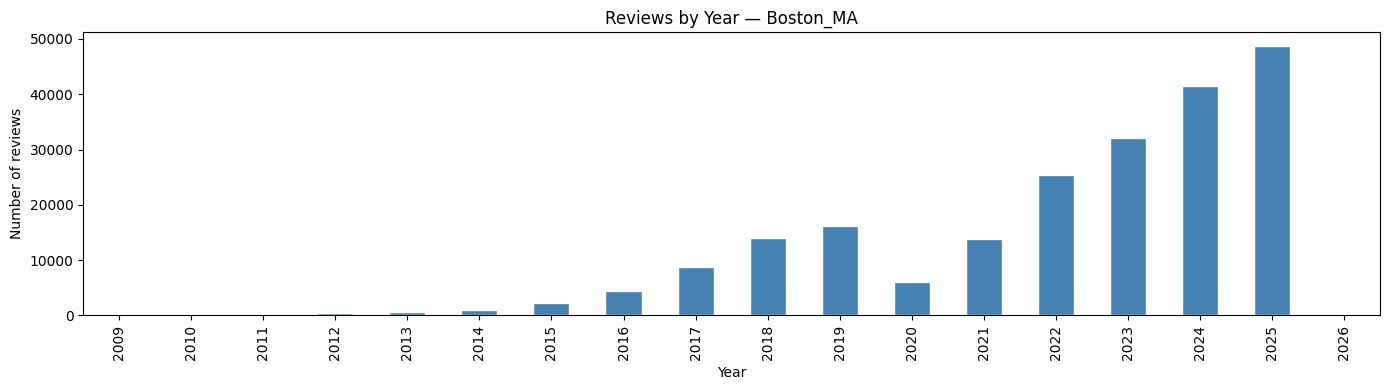

In [11]:
# Review date distribution
df_r["date"] = pd.to_datetime(df_r["date"], errors="coerce")

fig, ax = plt.subplots(figsize=(14, 4))
df_r["date"].dt.year.value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title(f"Reviews by Year — {CITY}")
ax.set_xlabel("Year")
ax.set_ylabel("Number of reviews")
plt.tight_layout()
plt.show()

In [ ]:
# Comment length distribution
df_r["comment_len"] = df_r["comments"].astype(str).str.len()

print(df_r["comment_len"].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(12, 4))
df_r["comment_len"].clip(upper=2000).hist(bins=60, ax=ax, color="mediumseagreen", edgecolor="white")
ax.set_title(f"Review Comment Length — {CITY} (capped 2000 chars)")
ax.set_xlabel("Character count")
plt.tight_layout()
plt.show()

In [ ]:
# Sample 5 random review comments
print("── Sample reviews ──\n")
for i, row in df_r["comments"].dropna().sample(5, random_state=42).items():
    print(f"[{i}] {str(row)[:300]}")
    print()

In [ ]:
# Can we join? Check listing_id in reviews matches id in listings
matched   = df_r["listing_id"].isin(df_l["id"]).sum()
unmatched = (~df_r["listing_id"].isin(df_l["id"])).sum()
print(f"Reviews matched to a listing : {matched:,}  ({matched/len(df_r)*100:.1f}%)")
print(f"Reviews with no matching listing: {unmatched:,}  ({unmatched/len(df_r)*100:.1f}%)")

---
## 4. All Cities — Summary Report
Loop through all 15 cities and build a side-by-side comparison **before** concatenating.  
This is the inspection step that runs before `pd.concat()` in `01_ingest.py`.


In [ ]:
report = []

for lpath in sorted(glob.glob(os.path.join(CSV_DIR, "listings_*_clean.csv"))):
    city_tag = os.path.basename(lpath).replace("listings_","").replace("_clean.csv","")
    rpath    = os.path.join(CSV_DIR, f"reviews_{city_tag}_clean.csv")

    if not os.path.exists(rpath):
        print(f"⚠️  Missing reviews for {city_tag}")
        continue

    _l = _read_listings(lpath)   # ← normalised IDs
    _r = _read_reviews(rpath)    # ← normalised IDs

    report.append({
        "city"              : city_tag,
        "listing_rows"      : len(_l),
        "review_rows"       : len(_r),
        "listing_cols"      : _l.shape[1],
        "dupe_listing_ids"  : int(_l["id"].duplicated().sum()),
        "null_rating_pct"   : round(_l["review_scores_rating"].isnull().mean()*100, 1)
                              if "review_scores_rating" in _l.columns else None,
        "null_comments_pct" : round(_r["comments"].isnull().mean()*100, 1)
                              if "comments" in _r.columns else None,
        "review_match_pct"  : round(_r["listing_id"].isin(_l["id"]).mean()*100, 1),
    })

report_df = pd.DataFrame(report)
report_df


,city,listing_rows,review_rows,listing_cols,dupe_listing_ids,null_rating_pct,price_dtype,median_price,listing_id_dtype,null_comments_pct,review_match_pct
0,Austin_TX,10533,588362,80,836,15.40,str,135.00,int64,0.10,66.10
1,Boston_MA,3706,215715,86,2075,22.20,float64,NaN,int64,0.20,69.20
2,Cambridge_MA,1358,76839,80,65,24.50,str,204.00,int64,0.20,78.50
3,Chicago_IL,8660,492465,80,743,19.40,str,153.00,int64,0.10,66.80
4,Denver_CO,4910,352162,80,73,12.40,str,123.00,int64,0.10,74.00
5,Hawaii_HI,33457,1409171,80,4277,20.10,str,233.00,int64,0.10,76.80
6,LosAngeles_CA,45585,1785848,86,0,26.80,float64,NaN,int64,0.30,70.00
7,Nashville_TN,9443,784894,80,789,10.50,str,158.00,int64,0.10,73.30
8,NewOrleans_LA,7444,489253,80,801,17.30,str,132.00,int64,0.10,79.30
9,NewYork_City_NY,36445,1003480,86,2864,31.50,float64,NaN,int64,0.20,73.40


In [ ]:
# Flag any potential issues
print("── Potential issues ──\n")

dupes = report_df[report_df["dupe_listing_ids"] > 0]
if len(dupes):
    print(f"⚠️  Cities with duplicate listing IDs:\n{dupes[['city','dupe_listing_ids']].to_string(index=False)}\n")

dtype_mismatch = report_df[report_df["listing_id_dtype"] != report_df["listing_id_dtype"].mode()[0]]
if len(dtype_mismatch):
    print(f"⚠️  Cities with different listing_id dtype:\n{dtype_mismatch[['city','listing_id_dtype']].to_string(index=False)}\n")

low_match = report_df[report_df["review_match_pct"] < 95]
if len(low_match):
    print(f"⚠️  Cities where <95% of reviews match a listing:\n{low_match[['city','review_match_pct']].to_string(index=False)}\n")

if not len(dupes) and not len(dtype_mismatch) and not len(low_match):
    print("✅  No issues found — safe to proceed with 01_ingest.py")

── Potential issues ──

⚠️  Cities with duplicate listing IDs:
           city  dupe_listing_ids
      Austin_TX               836
      Boston_MA              2075
   Cambridge_MA                65
     Chicago_IL               743
      Denver_CO                73
      Hawaii_HI              4277
   Nashville_TN               789
  NewOrleans_LA               801
NewYork_City_NY              2864
     Oakland_CA                42
    Portland_OR               200
SanFrancisco_CA               647
     Seattle_WA               366
  Washington_DC               535

⚠️  Cities where <95% of reviews match a listing:
           city  review_match_pct
      Austin_TX             66.10
      Boston_MA             69.20
   Cambridge_MA             78.50
     Chicago_IL             66.80
      Denver_CO             74.00
      Hawaii_HI             76.80
  LosAngeles_CA             70.00
   Nashville_TN             73.30
  NewOrleans_LA             79.30
NewYork_City_NY             73.40
  

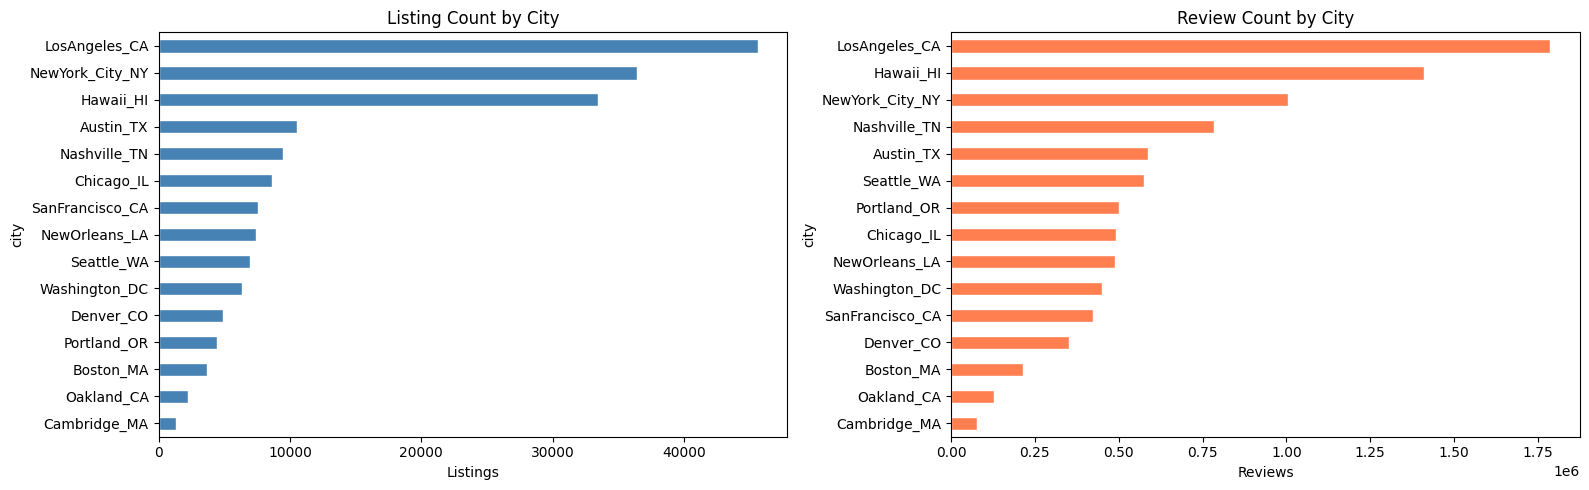

In [24]:
# Visual comparison — listing and review counts per city
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

report_df.set_index("city")["listing_rows"].sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Listing Count by City")
axes[0].set_xlabel("Listings")

report_df.set_index("city")["review_rows"].sort_values().plot(
    kind="barh", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Review Count by City")
axes[1].set_xlabel("Reviews")

plt.tight_layout()
plt.show()

---
## 5. Check SQLite DB (run after 01_ingest.py)
Only run this section after you have run `01_ingest.py` and the DB exists.


In [ ]:
if not os.path.exists(DB_PATH):
    print("⚠️  airbnb.db not found — run 01_ingest.py first.")
else:
    con = sqlite3.connect(DB_PATH) # alwyas connect once we're ready to explore the DB

    tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)
    print("Tables in DB:", tables["name"].tolist())

    print("\n── Listings ──")
    print(pd.read_sql("SELECT COUNT(*) as rows, COUNT(DISTINCT city_tag) as cities FROM listings", con).to_string(index=False))

    print("\n── Reviews ──")
    print(pd.read_sql("SELECT COUNT(*) as rows, COUNT(DISTINCT city_tag) as cities FROM reviews", con).to_string(index=False))

    con.close()

Tables in DB: ['listings', 'reviews']

── Listings ──
  rows  cities
189151      15

── Reviews ──
   rows  cities
9106491      15


In [33]:
# Query a single city from the DB
if os.path.exists(DB_PATH):
    con = sqlite3.connect(DB_PATH)
    df = pd.read_sql("""
        SELECT * FROM reviews 
        WHERE city_tag = 'Boston_MA' 
        LIMIT 10
    """, con)
    display(df)
else:
    print("⚠️  airbnb.db not found — run 01_ingest.py first.")


,listing_id,id,date,reviewer_id,reviewer_name,comments,city_tag
0,3781,37776825,2015-07-10,36059247,Greg,The apartment was as advertised and Frank was incredibly helpful through the...,Boston_MA
1,3781,41842494,2015-08-09,10459388,Tai,It was a pleasure to stay at Frank's place. The place has everything you nee...,Boston_MA
2,3781,45282151,2015-09-01,12264652,Damien,"The apartment description is entirely faithful, and the building very well m...",Boston_MA
3,3781,49022647,2015-09-30,41426327,Mike,"Thoroughly enjoyed my time at Frank's home. Had all amenities, was very clea...",Boston_MA
4,3781,52503327,2015-10-30,15151513,Ivan,Great value for the money! This location has exceeding my expectations. <br...,Boston_MA
5,3781,63371931,2016-02-22,55456499,John-Mark,Frank was very accommodating throughout my stay in East Boston. He is easy t...,Boston_MA
6,3781,67909504,2016-04-01,55456499,John-Mark,Excellent! This was my second stay at the Jeffries St location and once agai...,Boston_MA
7,3781,97906006,2016-08-28,88528884,Elisa,Frank was a wonderful and accommodating host. He was responsive to any quest...,Boston_MA
8,3781,105143774,2016-09-30,1342806,Nicole,"Frank was great, the apartment has everything we need, including parking and...",Boston_MA
9,3781,129692749,2017-02-01,55126634,Carlos,Very nice. Comfortable apartment. Good location. Frank is very nice person.,Boston_MA


In [ ]:
# Row counts per city from DB
if os.path.exists(DB_PATH):
    con = sqlite3.connect(DB_PATH)
    listing_counts = pd.read_sql(
        "SELECT city_tag, COUNT(*) as listings FROM listings GROUP BY city_tag ORDER BY listings DESC", con)
    review_counts  = pd.read_sql(
        "SELECT city_tag, COUNT(*) as reviews  FROM reviews  GROUP BY city_tag ORDER BY reviews  DESC", con)
    con.close()

    summary = listing_counts.merge(review_counts, on="city_tag")
    summary["reviews_per_listing"] = (summary["reviews"] / summary["listings"]).round(1)
    summary

In [35]:
# Listings with most reviews
pd.read_sql("""
    SELECT listing_id,city_tag, COUNT(*) as review_count 
    FROM reviews 
    GROUP BY listing_id 
    ORDER BY review_count DESC 
    LIMIT 10
""", con)

,listing_id,city_tag,review_count
0,858697692672545141,NewYork_City_NY,3924
1,54227245,Nashville_TN,3369
2,42409434,LosAngeles_CA,3059
3,51619634,NewYork_City_NY,2174
4,691676460109271194,NewYork_City_NY,2036
5,37122502,NewYork_City_NY,1909
6,565317486488599327,NewOrleans_LA,1806
7,34122310,Portland_OR,1777
8,750089121447866329,NewOrleans_LA,1740
9,1733052,Denver_CO,1697


New York City, NY has the highest review counts. 

In [36]:
# Check uniqueness on (id + city_tag) combined
pd.read_sql("""
    SELECT 
        COUNT(*)                       as total_rows,
        COUNT(DISTINCT id || city_tag) as distinct_id_city,
        COUNT(*) - COUNT(DISTINCT id || city_tag) as true_duplicates
    FROM reviews
""", con)

,total_rows,distinct_id_city,true_duplicates
0,9106491,9106416,75


In [38]:
pd.read_sql("""
    SELECT id, city_tag, listing_id, date, reviewer_id, COUNT(*) as count
    FROM reviews
    GROUP BY id, city_tag
    HAVING COUNT(*) > 1
    ORDER BY count DESC
    LIMIT 80
""", con)

,id,city_tag,listing_id,date,reviewer_id,count
0,759942595,Seattle_WA,750913851705799630,2021-05-18,39186665,2
1,763837879,Seattle_WA,750913851705799630,2021-05-29,30602248,2
2,765473118,Seattle_WA,750913851705799630,2021-06-01,14769587,2
3,768659809,Seattle_WA,750913851705799630,2021-06-10,4018618,2
4,439920893123137491,Seattle_WA,750913851705799630,2021-08-29,211754838,2
...,...,...,...,...,...,...
70,1360411246489755178,SanFrancisco_CA,1295653283406874784,2025-02-19,191195962,2
71,1368392340475398624,SanFrancisco_CA,1295653283406874784,2025-03-02,132102213,2
72,1369119026319606980,SanFrancisco_CA,1295653283406874784,2025-03-03,65587776,2
73,1371914976492462078,SanFrancisco_CA,1295653283406874784,2025-03-07,37403796,2


In [49]:
pd.read_sql("""SELECT id, COUNT(*) as cnt
FROM listings
GROUP BY id
HAVING cnt > 1
            """, con)

,id,cnt
0,541841000000000000.00,2
1,542648000000000000.00,2
2,545000000000000000.00,3
3,545126000000000000.00,2
4,547033000000000000.00,2
...,...,...
12994,1617570000000000000.00,2
12995,1617740000000000000.00,5
12996,1618200000000000000.00,2
12997,1618220000000000000.00,2
